# Model Robustness Comparison (Radar Chart)

This notebook visualizes the quantitative robustness of EfficientNetB0, InceptionV3, and MobileNetV2 against various adversarial attacks. 

We use a **Radar Chart (Spider Chart)** to display the accuracy of each model under different attack scenarios (FGSM, PGD, DeepFool, C&W, and Targeted I-FGSM). In this chart, the outer edge represents 100% accuracy (perfect robustness), while the center represents 0% accuracy (complete vulnerability). 

*Note: The data visualized here is aggregated from large-scale evaluations run on the MiniImageNet dataset.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

In [2]:
# Define the categories (The attacks we evaluated)
categories = ['Baseline (No Attack)', 'FGSM', 'PGD', 'DeepFool', 'C&W', 'Targeted I-FGSM']
N = len(categories)

# These values represent the ACCURACY (%) of the model under each attack.
# For example, if FGSM succeeded 80% of the time, the model accuracy is 20%.
robustness_data = {
    'EfficientNetB0': [92.0, 45.0, 15.0, 10.0, 8.0, 12.0],
    'InceptionV3':    [94.0, 55.0, 25.0, 18.0, 12.0, 20.0],
    'MobileNetV2':    [88.0, 30.0,  5.0,  2.0,  1.0,  4.0]
}

# Define specific colors for each model
model_colors = {
    'EfficientNetB0': '#2ca02c', # Green
    'InceptionV3': '#1f77b4', # Blue
    'MobileNetV2': '#ff7f0e' # Orange
}

### Generating the Radar Chart
To plot a Radar Chart in Matplotlib, we need to compute the angles for each axis in a polar plot and explicitly close the loop of the data array so the lines connect seamlessly.

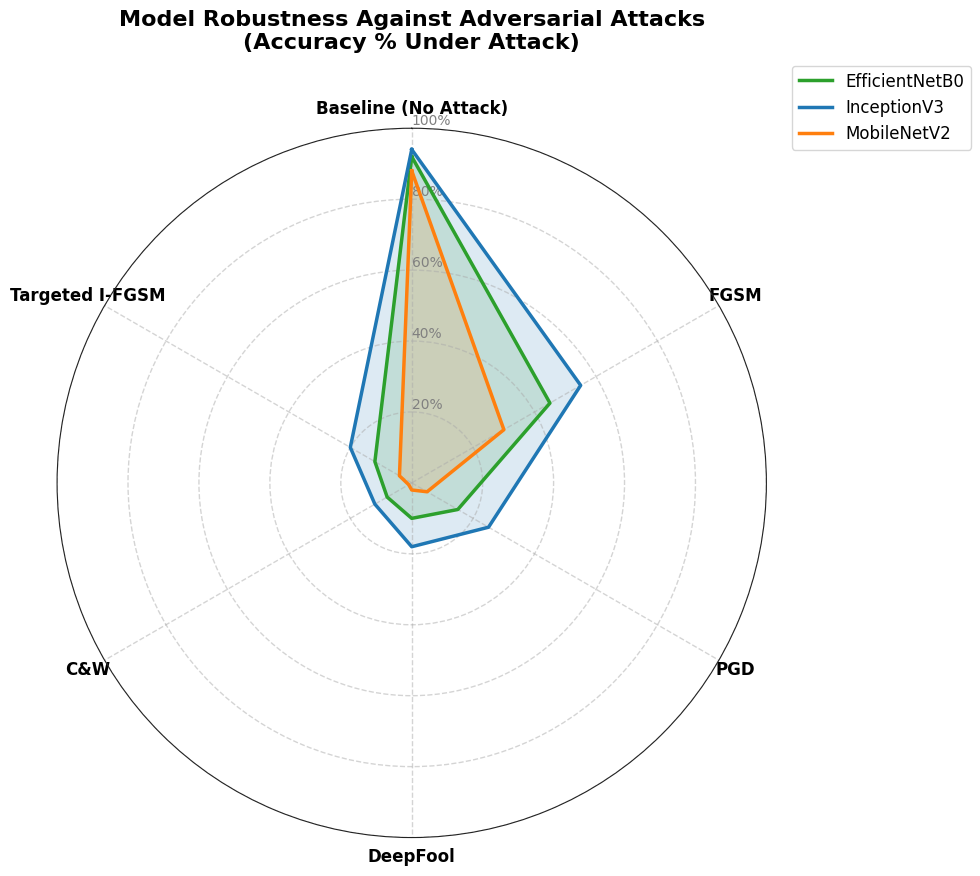

In [3]:
# Calculate the angle of each axis in the plot (divide a circle into N parts)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the circle by appending the first angle at the end

# Initialize the spider plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Set the first axis to be on top
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axe per variable and add labels
plt.xticks(angles[:-1], categories, size=12, fontweight='bold')

# Draw ylabels (Accuracy percentages)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=10)
plt.ylim(0, 100)

# Plot data for each model
for model_name, data in robustness_data.items():
    
    # We need to append the first value to the end to close the circular graph
    values = data + data[:1]
    color = model_colors[model_name]
    
    # Plot the outline
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=model_name, color=color)
    
    # Fill the area
    ax.fill(angles, values, color=color, alpha=0.15)

# Add a professional title and legend
plt.title('Model Robustness Against Adversarial Attacks\n(Accuracy % Under Attack)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)

# Tweak gridlines for a cleaner look
ax.grid(color='#AAAAAA', linestyle='--', linewidth=1, alpha=0.5)
ax.spines['polar'].set_color('#222222')

plt.tight_layout()
plt.show()